# Phase 2 : Analyse Exploratoire des Données (AED)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

* Chargement du dataset nettoyé.

In [16]:
df = pd.read_csv('../data/framingham_heart_study_clean.csv')
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (4240, 27)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,pulse_pressure,age_sysBP,smoke_chol,BMI_Interpret_Insuffisance ponderale,BMI_Interpret_Obesite,BMI_Interpret_Surpoids,Tension_Hypertension,Tension_Normale,heartRate_Interpret_Normale,heartRate_Interpret_Tachycardie
0,1,39,4,0,0,0,0,0,0,195.0,...,36.0,4134.0,0.0,0,0,1,0,1,1,0
1,0,46,2,0,0,0,0,0,0,250.0,...,40.0,5566.0,0.0,0,0,1,1,0,1,0
2,1,48,1,1,20,0,0,0,0,245.0,...,47.5,6120.0,4900.0,0,0,1,1,0,1,0
3,0,61,3,1,30,0,0,1,0,225.0,...,55.0,9150.0,6750.0,0,0,1,1,0,1,0
4,0,46,3,1,23,0,0,0,0,285.0,...,46.0,5980.0,6555.0,0,0,0,1,0,1,0


* Vérification rapide avant de commencer.

In [17]:
print("Valeurs manquantes :", df.isnull().sum().sum())
print("Doublons :", df.duplicated().sum())
print("\nDistribution de la cible :")
print(df["TenYearCHD"].value_counts())

Valeurs manquantes : 0
Doublons : 0

Distribution de la cible :
TenYearCHD
0    3596
1     644
Name: count, dtype: int64


* Définition des listes de variables continues et catégorielles.

In [18]:
var_continues = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI',
                 'heartRate', 'glucose', 'risk_score', 'pulse_pressure']

var_cat = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke',
           'prevalentHyp', 'diabetes',
           'BMI_Interpret_Insuffisance ponderale', 'BMI_Interpret_Obesite', 'BMI_Interpret_Surpoids',
           'Tension_Hypertension', 'Tension_Normale',
           'heartRate_Interpret_Normale', 'heartRate_Interpret_Tachycardie',
           'TenYearCHD']

## 1. Analyse univariée

* Histogrammes pour les variables continues.

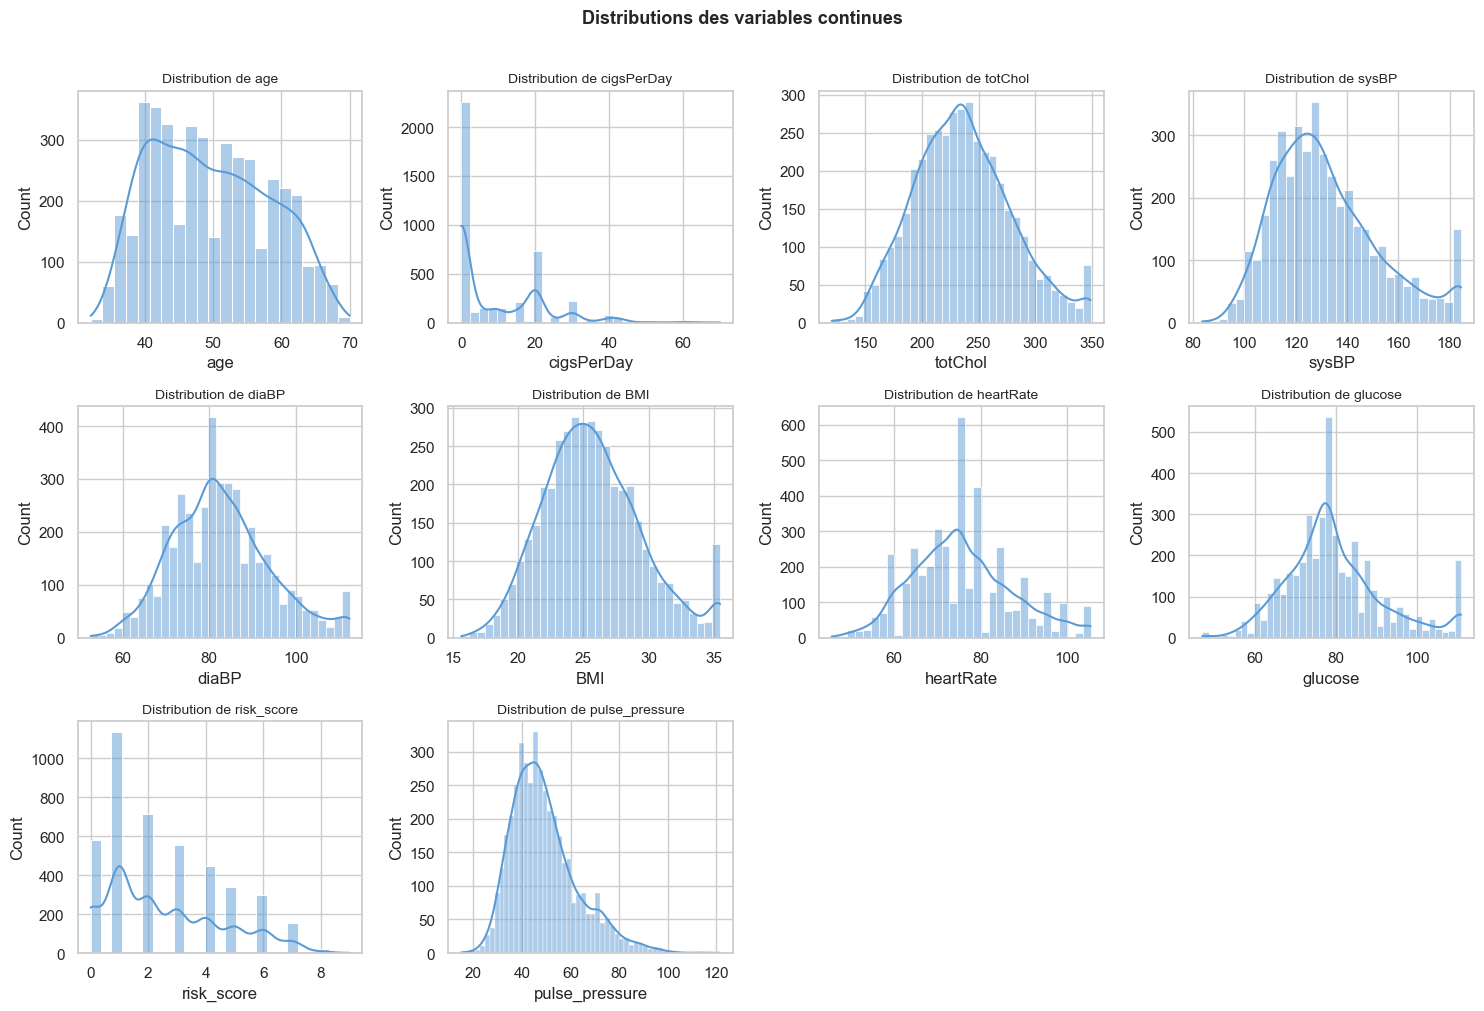

In [19]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(var_continues):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[feature], kde=True, color="#5B9BD5")
    plt.title(f"Distribution de {feature}", fontsize=10)
plt.suptitle("Distributions des variables continues", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

* Statistiques descriptives par classe (CHD / Non CHD).

In [20]:
# utile pour voir rapidement les différences entre les deux groupes
stats_by_class = df.groupby("TenYearCHD")[var_continues].mean().T.round(2)
stats_by_class.columns = ["Non CHD (0)", "CHD (1)"]
stats_by_class["Diff (CHD - Non CHD)"] = (stats_by_class["CHD (1)"] - stats_by_class["Non CHD (0)"]).round(2)
print("Moyennes par classe (CHD vs Non CHD) :")
print(stats_by_class)

Moyennes par classe (CHD vs Non CHD) :
                Non CHD (0)  CHD (1)  Diff (CHD - Non CHD)
age                   48.76    54.15                  5.39
cigsPerDay             8.65    10.60                  1.95
totChol              234.78   244.14                  9.36
sysBP                130.08   142.14                 12.06
diaBP                 82.07    86.53                  4.46
BMI                   25.60    26.35                  0.75
heartRate             75.64    76.38                  0.74
glucose               79.40    81.72                  2.32
risk_score             2.33     3.68                  1.35
pulse_pressure        48.02    55.61                  7.59


## 2. Analyse bivariée

* Relation entre la variable cible et les variables continues (boxplots).

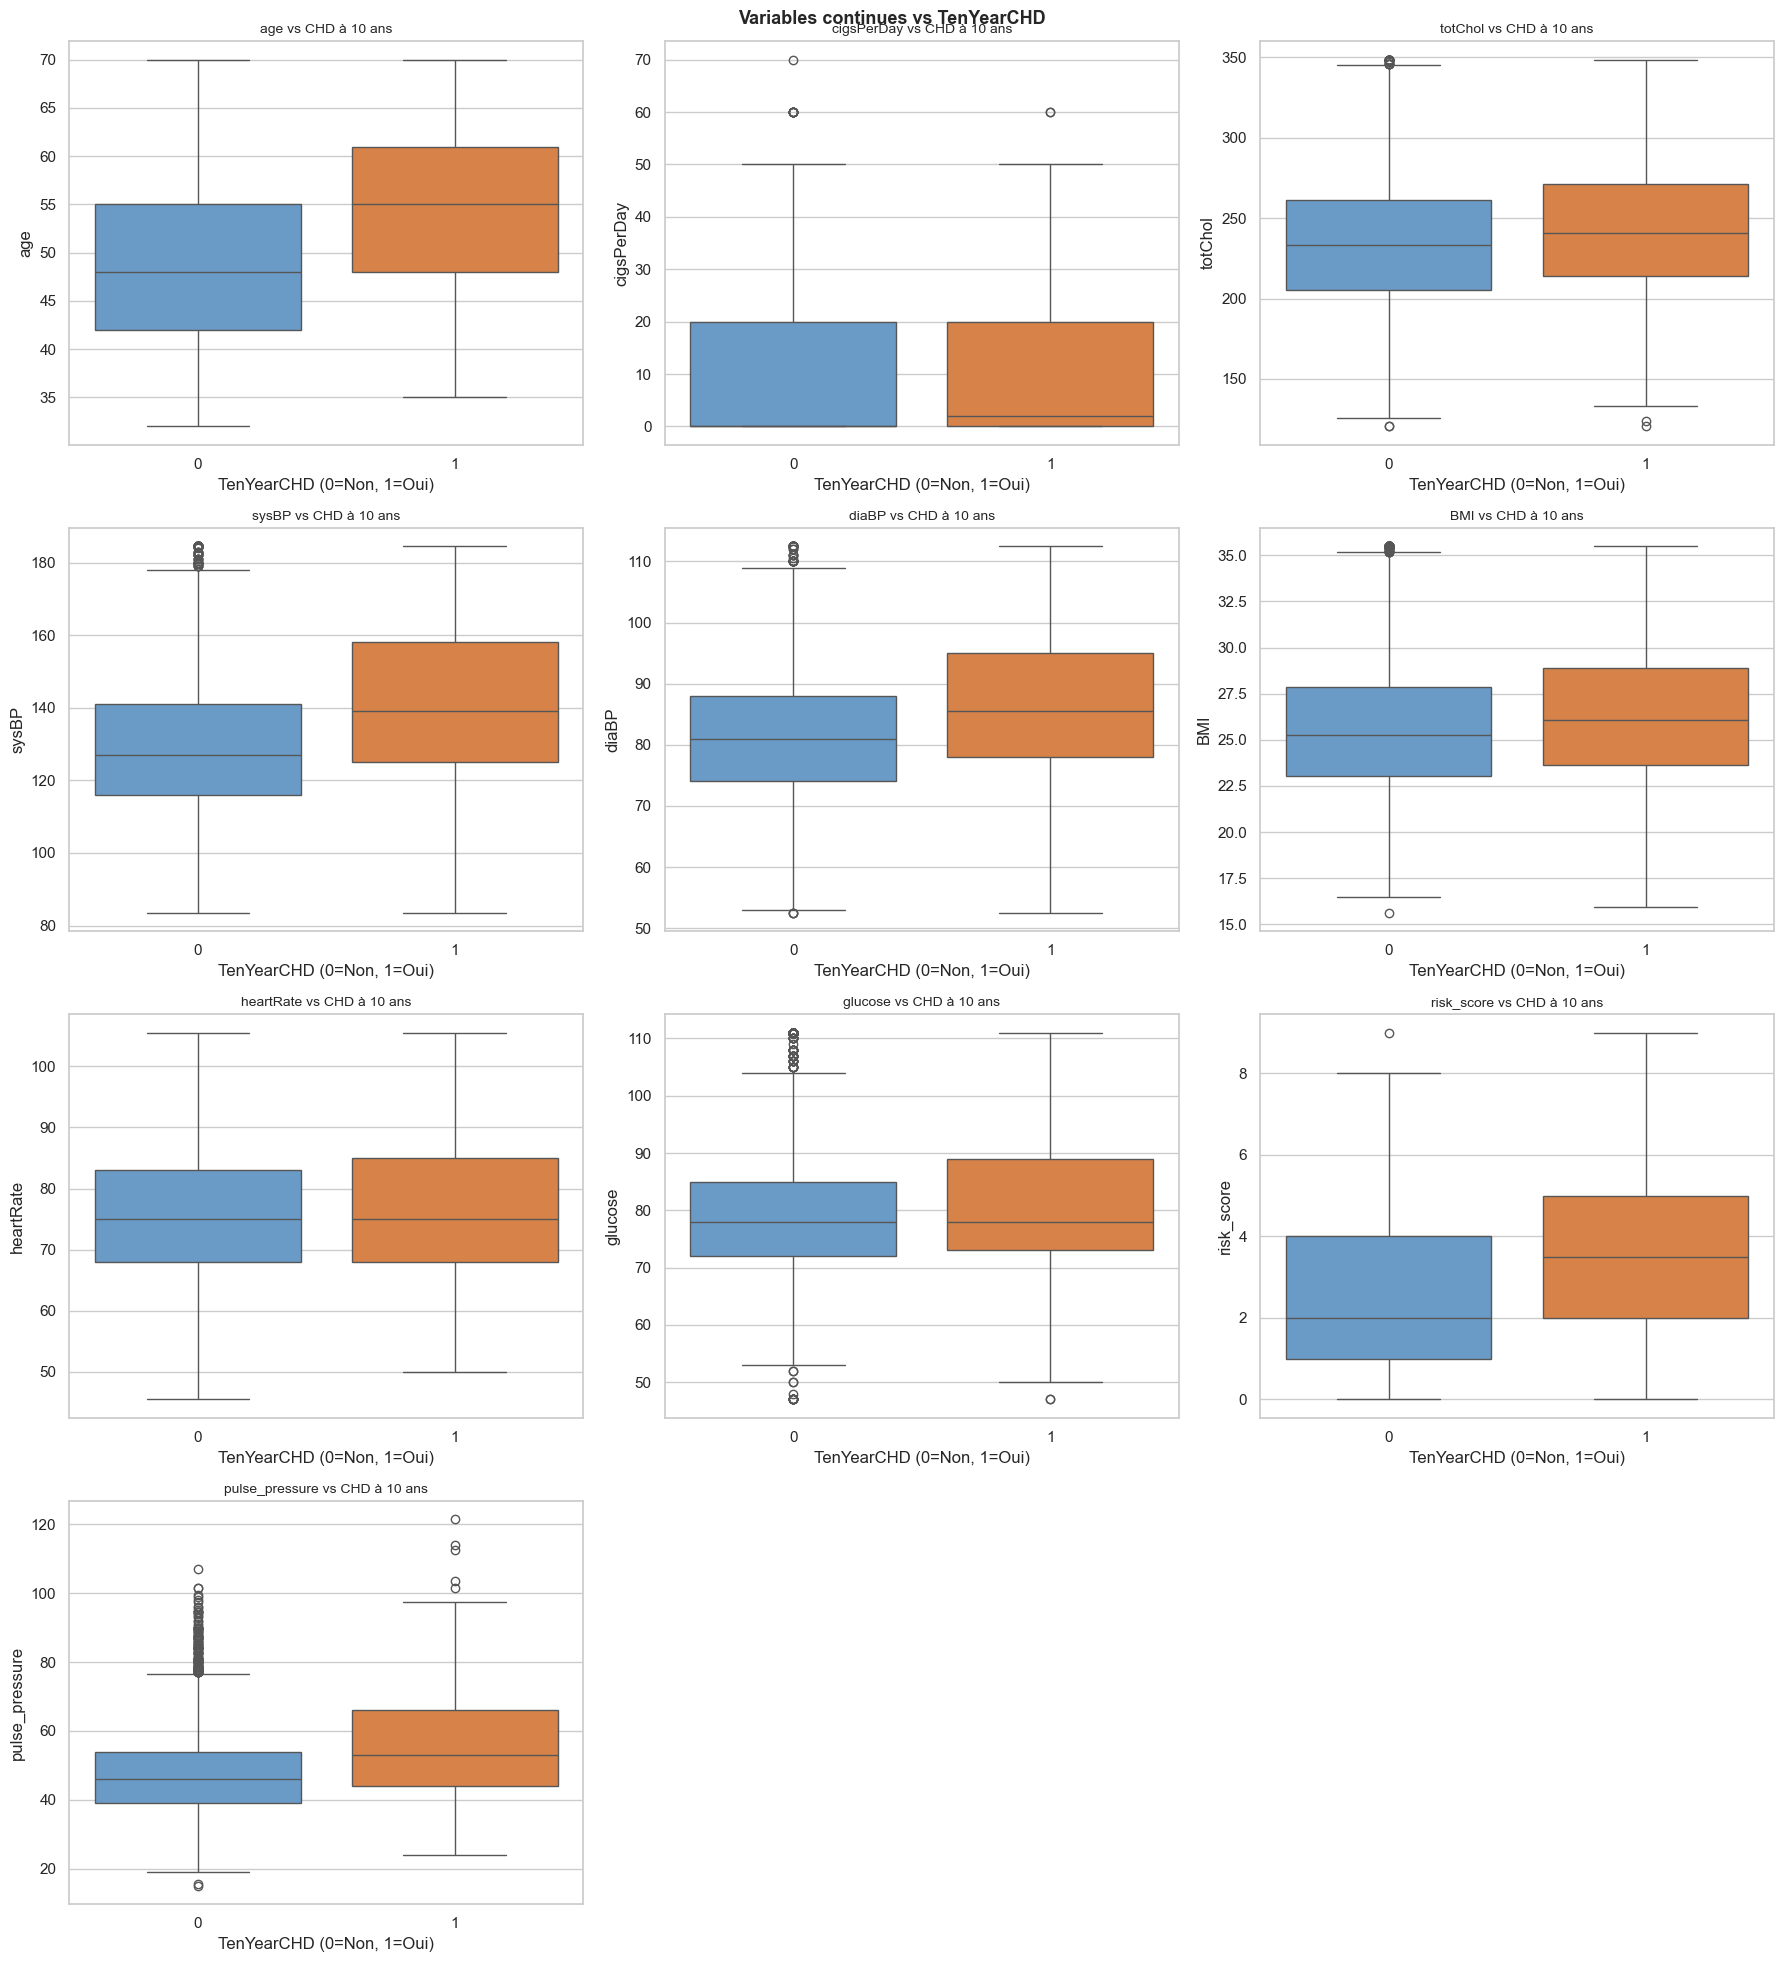

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(var_continues):
    # on ajoute la médiane pour chaque groupe directement sur le boxplot
    sns.boxplot(x="TenYearCHD", y=col, data=df, ax=axes[i],
                palette=["#5B9BD5", "#ED7D31"])
    axes[i].set_title(f"{col} vs CHD à 10 ans", fontsize=10)
    axes[i].set_xlabel("TenYearCHD (0=Non, 1=Oui)")

# supprimer les axes vides si il y en a
for j in range(len(var_continues), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variables continues vs TenYearCHD", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

* Taux de CHD par tranche d'âge.

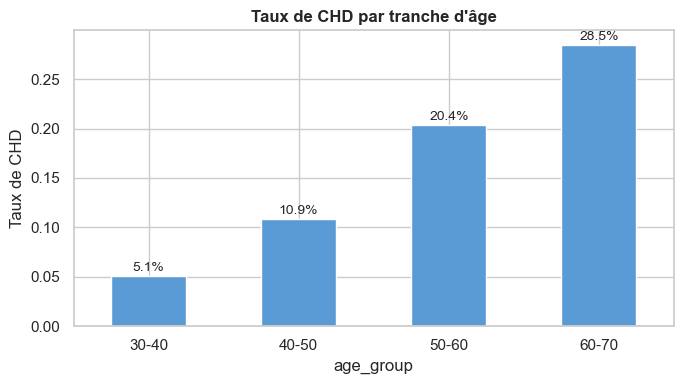

In [22]:
# l'âge est la variable la plus corrélée, on creuse un peu
df["age_group"] = pd.cut(df["age"], bins=[30, 40, 50, 60, 70],
                         labels=["30-40", "40-50", "50-60", "60-70"])

taux_age = df.groupby("age_group", observed=True)["TenYearCHD"].mean()

plt.figure(figsize=(7, 4))
taux_age.plot(kind="bar", color="#5B9BD5", edgecolor="white", rot=0)
plt.ylabel("Taux de CHD")
plt.title("Taux de CHD par tranche d'âge", fontweight="bold")
for i, v in enumerate(taux_age):
    plt.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

df.drop(columns=["age_group"], inplace=True)

* Relation entre la variable cible et les variables catégorielles (tableaux de contingence et diagrammes groupés).


Tableau de contingence : male vs TenYearCHD
TenYearCHD     0    1
male                 
0           2119  301
1           1477  343

Tableau de contingence : education vs TenYearCHD
TenYearCHD     0    1
education            
1           1486  339
2           1106  147
3            601   88
4            403   70

Tableau de contingence : currentSmoker vs TenYearCHD
TenYearCHD        0    1
currentSmoker           
0              1834  311
1              1762  333

Tableau de contingence : BPMeds vs TenYearCHD
TenYearCHD     0    1
BPMeds               
0           3513  603
1             83   41

Tableau de contingence : prevalentStroke vs TenYearCHD
TenYearCHD          0    1
prevalentStroke           
0                3582  633
1                  14   11

Tableau de contingence : prevalentHyp vs TenYearCHD
TenYearCHD       0    1
prevalentHyp           
0             2604  319
1              992  325

Tableau de contingence : diabetes vs TenYearCHD
TenYearCHD     0    1
diabetes    

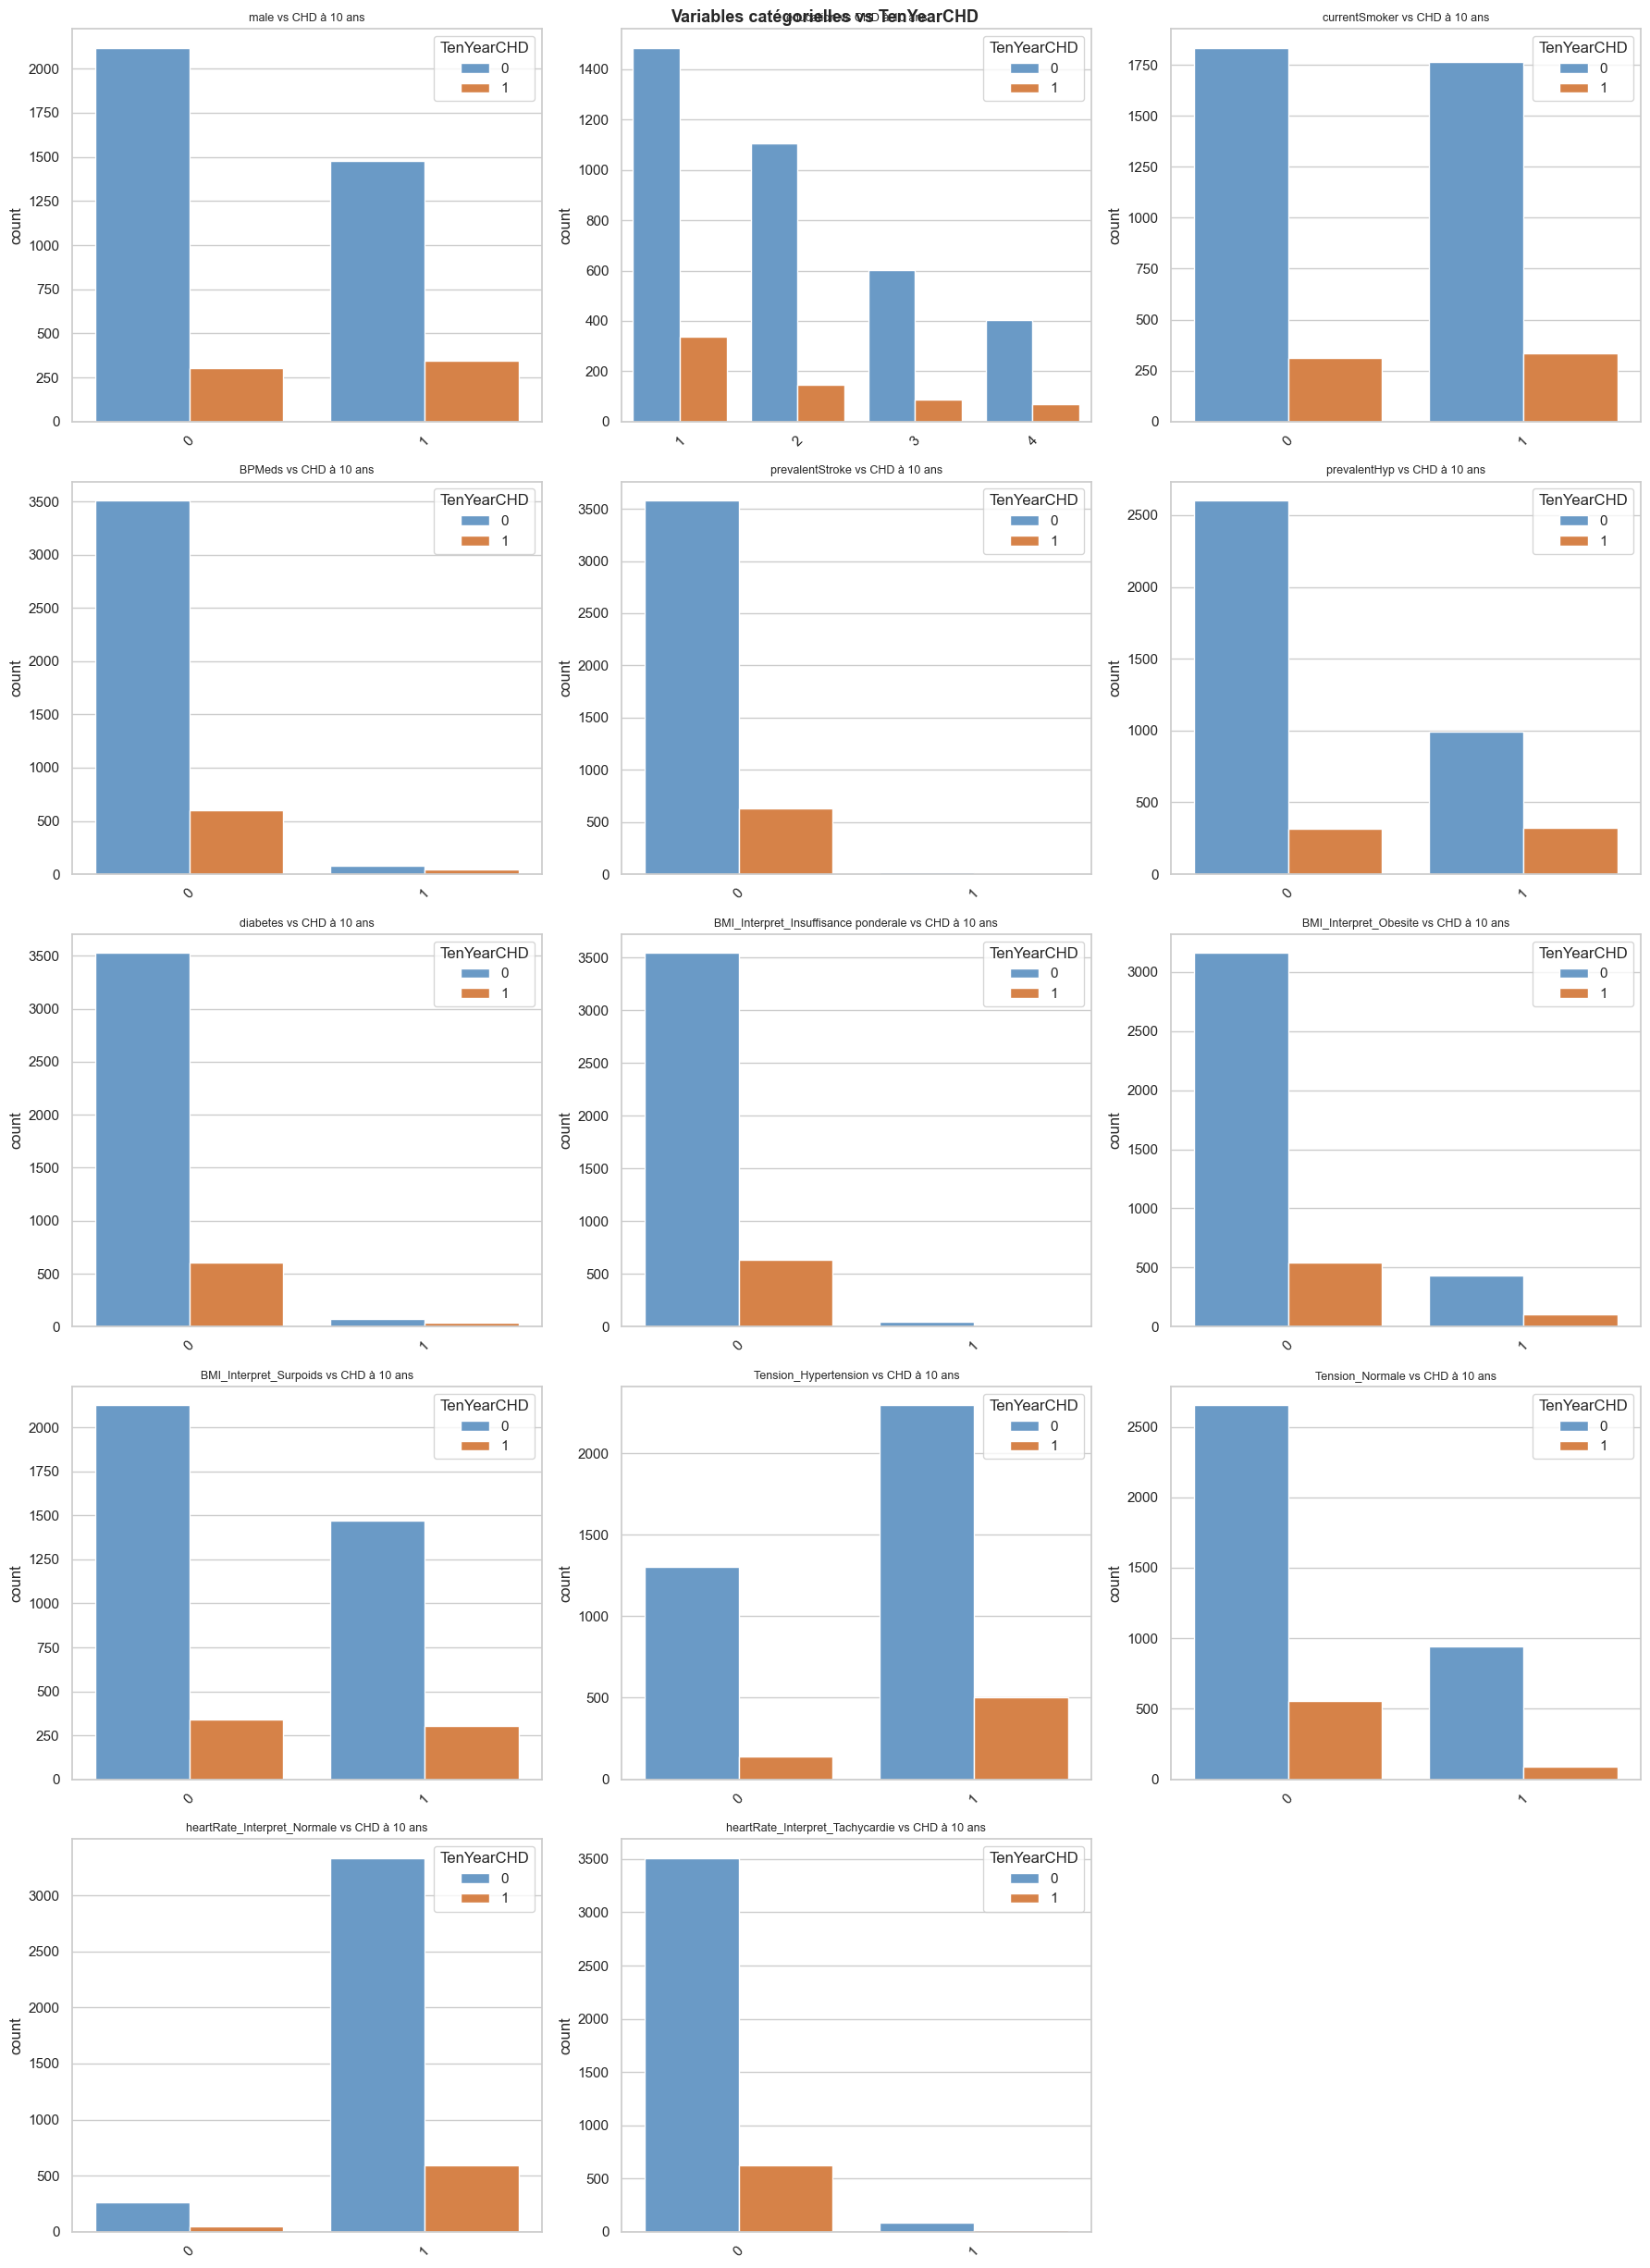

In [23]:
# on enlève TenYearCHD de la liste pour ne pas la tracer contre elle-même
cat_a_tracer = [c for c in var_cat if c != "TenYearCHD"]

fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(cat_a_tracer):
    # tableau de contingence
    print(f"\nTableau de contingence : {col} vs TenYearCHD")
    print(pd.crosstab(df[col], df["TenYearCHD"]))

    sns.countplot(x=col, hue="TenYearCHD", data=df, ax=axes[i],
                  palette=["#5B9BD5", "#ED7D31"])
    axes[i].set_title(f"{col} vs CHD à 10 ans", fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_a_tracer), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Variables catégorielles vs TenYearCHD", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

* Pairplot sur les variables les plus corrélées à la cible.

Le pairplot est limité aux variables continues les plus corrélées à `TenYearCHD` pour rester lisible. Représenter l'ensemble des variables encodées produirait un graphique illisible.

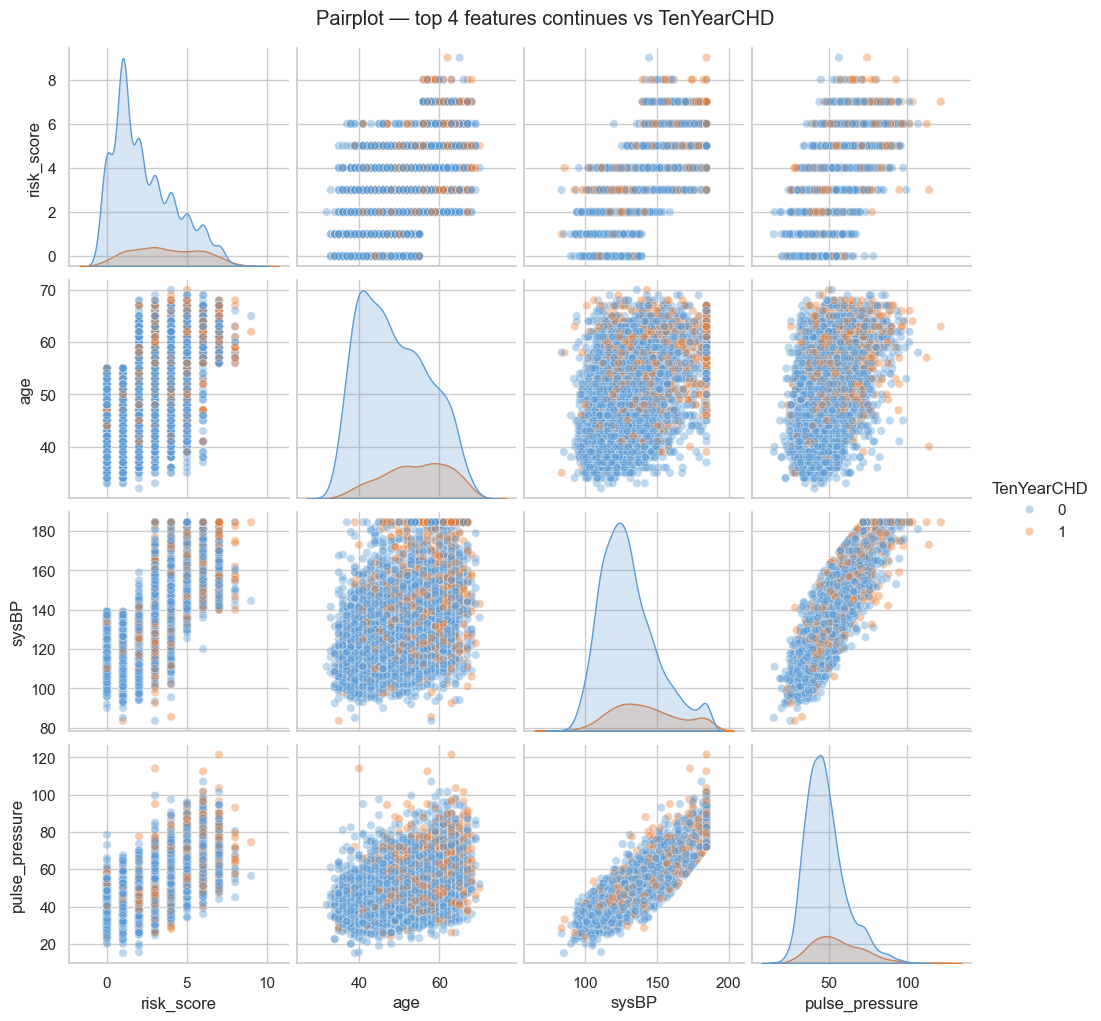

In [24]:
top_cont = (
    df[var_continues + ['TenYearCHD']]
    .corrwith(df['TenYearCHD'])
    .abs()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
if 'TenYearCHD' not in top_cont:
    top_cont.append('TenYearCHD')

sns.pairplot(df[top_cont], hue='TenYearCHD',
             palette={0: "#5B9BD5", 1: "#ED7D31"}, plot_kws={"alpha": 0.4})
plt.suptitle("Pairplot — top 4 features continues vs TenYearCHD", y=1.02)
plt.show()

## 3. Matrice de corrélation

* Calcul et visualisation (heatmap).

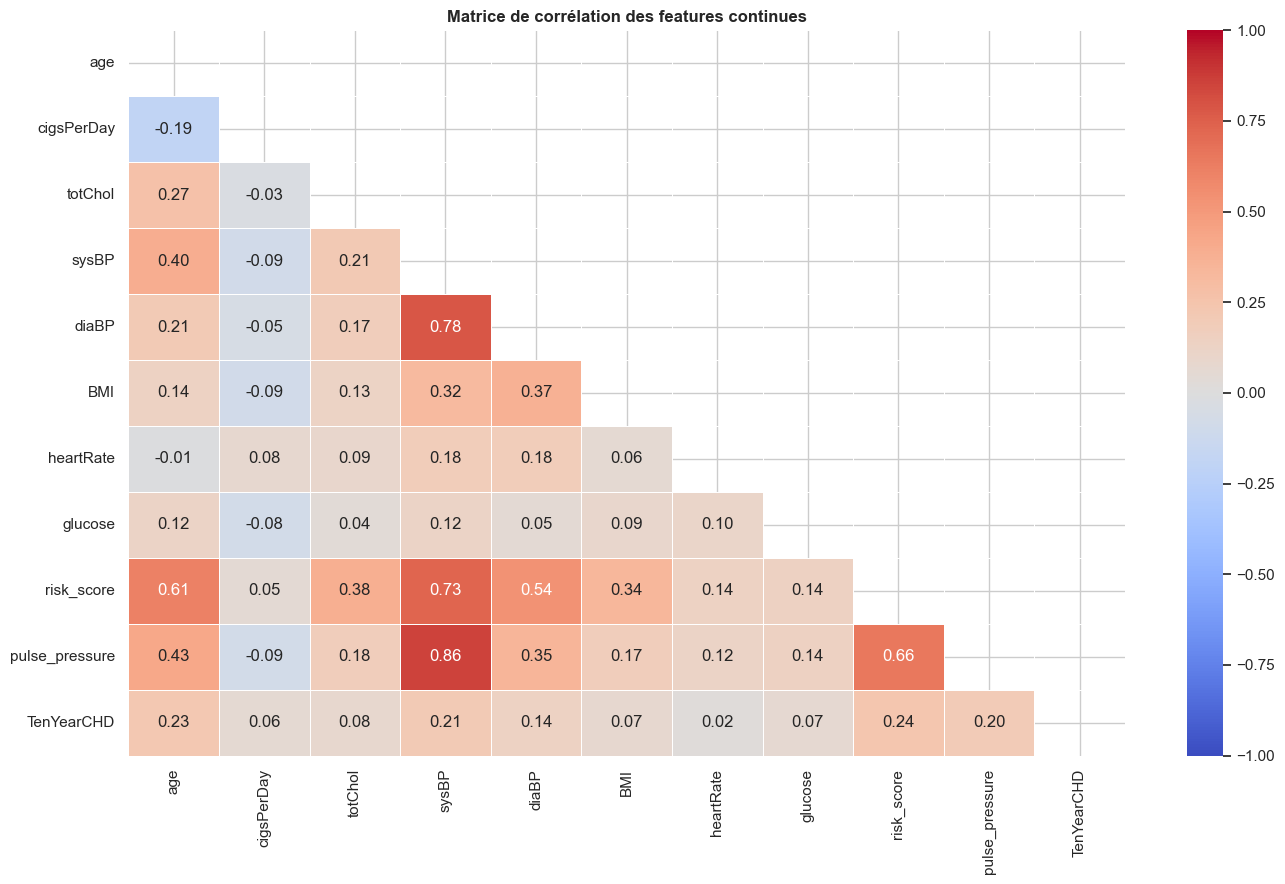

In [25]:
col_corr = var_continues + ["TenYearCHD"]
cor = df[col_corr].corr()

plt.figure(figsize=(14, 9))
mask = np.triu(np.ones_like(cor, dtype=bool))   # on masque la moitié sup pour lisibilité
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice de corrélation des features continues', fontweight="bold")
plt.tight_layout()
plt.show()

* Identification des corrélations fortes avec la cible et discussion sur la multicolinéarité.

In [26]:
corr_target = cor['TenYearCHD'].abs().sort_values(ascending=False)
top_4_corr_features = corr_target.head(5).index.tolist()
print("Variables les plus corrélées à TenYearCHD :")
print(corr_target.head(5))

Variables les plus corrélées à TenYearCHD :
TenYearCHD        1.000000
risk_score        0.241121
age               0.225408
sysBP             0.209623
pulse_pressure    0.198932
Name: TenYearCHD, dtype: float64


On remarque une forte colinéarité entre `age_sysBP` et `sysBP` d'une part,
et entre `risk_score` et plusieurs variables individuelles d'autre part.
Ces redondances sont attendues et seront gérées lors de la sélection des features.

## 4. Tests statistiques pour les variables catégorielles

* Test du Chi-deux pour les variables catégorielles.

Le test du Chi-deux permet de mesurer l'association entre chaque variable catégorielle
et la variable cible. Un p-value inférieur à 0.05 indique une association significative.

In [27]:
cat_cols = [c for c in var_cat if c != 'TenYearCHD']
results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["TenYearCHD"])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({
        "Variable": col,
        "Chi2": round(chi2, 3),
        "p-value": round(p, 4),
        "Significatif (p<0.05)": "Oui" if p < 0.05 else "Non"
    })

results_df = pd.DataFrame(results).sort_values("Chi2", ascending=False)
print(results_df.to_string(index=False))

                            Variable    Chi2  p-value Significatif (p<0.05)
                        prevalentHyp 132.456   0.0000                   Oui
                Tension_Hypertension  50.476   0.0000                   Oui
                     Tension_Normale  45.134   0.0000                   Oui
                            diabetes  38.482   0.0000                   Oui
                                male  32.618   0.0000                   Oui
                           education  31.052   0.0000                   Oui
                              BPMeds  30.273   0.0000                   Oui
                     prevalentStroke  14.034   0.0002                   Oui
              BMI_Interpret_Surpoids   8.725   0.0031                   Oui
               BMI_Interpret_Obesite   8.452   0.0036                   Oui
                       currentSmoker   1.497   0.2211                   Non
     heartRate_Interpret_Tachycardie   0.956   0.3281                   Non
BMI_Interpre

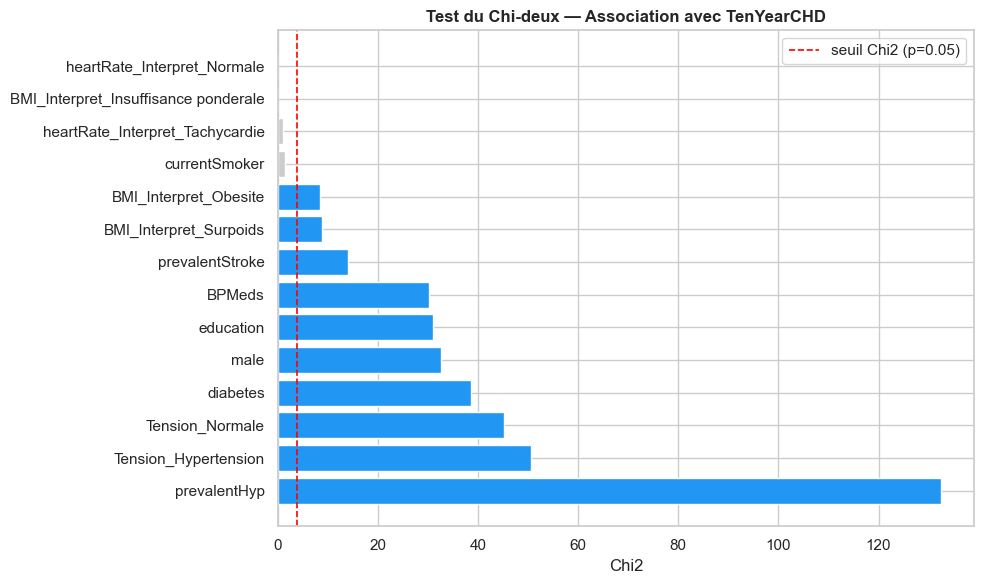

Bleu = significatif (p < 0.05)


In [28]:
# petite visu pour repérer rapidement les variables significatives
fig, ax = plt.subplots(figsize=(10, 6))
colors_chi = ["#2196F3" if s == "Oui" else "#ccc" for s in results_df["Significatif (p<0.05)"]]
ax.barh(results_df["Variable"], results_df["Chi2"], color=colors_chi, edgecolor="white")
ax.axvline(3.84, color="red", linestyle="--", lw=1.2, label="seuil Chi2 (p=0.05)")
ax.set_xlabel("Chi2")
ax.set_title("Test du Chi-deux — Association avec TenYearCHD", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
print("Bleu = significatif (p < 0.05)")

## 5. Sélection des features

* Corrélation absolue de toutes les features avec la variable cible.

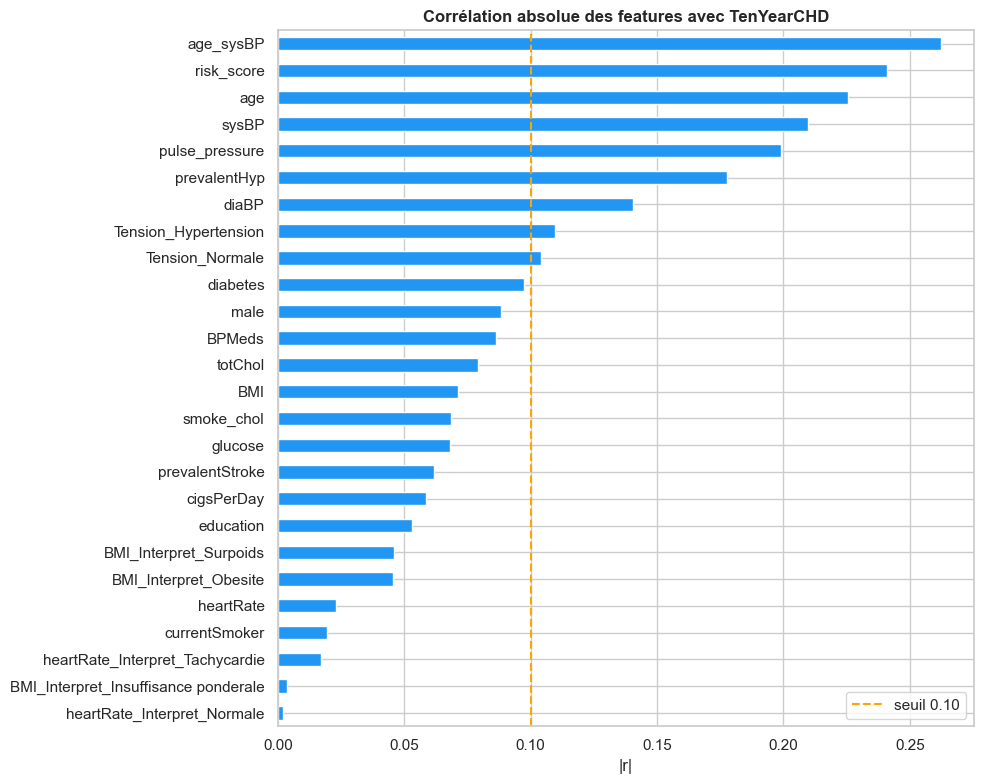

In [29]:
top_features = (
    df.drop('TenYearCHD', axis=1)
    .corrwith(df['TenYearCHD'])
    .abs()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='#2196F3', edgecolor="white")
plt.axvline(0.1, color='orange', linestyle='--', label='seuil 0.10')
plt.title("Corrélation absolue des features avec TenYearCHD", fontweight='bold')
plt.xlabel("|r|")
plt.legend()
plt.tight_layout()
plt.show()

* Sélection indicative des features et export.

Les 11 features présentant la corrélation absolue la plus élevée avec `TenYearCHD`
sont sélectionnées ici à titre indicatif, sur l'ensemble du dataset (pas de fuite
d'information car c'est une sélection non-supervisée par rapport à la cible).
Cette liste sera utilisée comme point de départ pour la modélisation.

In [30]:
important_features = top_features.sort_values(ascending=False).head(11).index.tolist()
important_features.append("TenYearCHD")

print("Features sélectionnées :")
print(important_features)

df[important_features].to_csv("../data/top_features.csv", index=False)
print(f"\nFichier exporté : top_features.csv — {len(important_features)-1} features + cible")

Features sélectionnées :
['age_sysBP', 'risk_score', 'age', 'sysBP', 'pulse_pressure', 'prevalentHyp', 'diaBP', 'Tension_Hypertension', 'Tension_Normale', 'diabetes', 'male', 'TenYearCHD']

Fichier exporté : top_features.csv — 11 features + cible
